#### **Importing all the Libraries**

In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### **1. Loading the original object's photo and the new cross angle photo**

In [6]:
img1 = cv2.imread("image1.jpg")
img2 = cv2.imread("image2.jpg")
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)


#### **2. Initialize the ORB Detector and match Features**

In [7]:
max_features = 2000
orb = cv2.ORB_create(nfeatures=max_features)
kp1,des1 = orb.detectAndCompute(gray1,None)
kp2,des2 = orb.detectAndCompute(gray2,None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=False)
raw_matches = bf.knnMatch(des1,des2,k=2)
good_matches = []
for m, n in raw_matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches[:50], None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

#### **3.Console Output Log and Visualization**

--- [TASK 7 FEATURE MATCHING LOG] ---
Total Good Matches Found (After Ratio Test): 27
Dominant Object Cluster: High-contrast rigid items (e.g., printed pen bodies and watch faces)
---------------------------------------


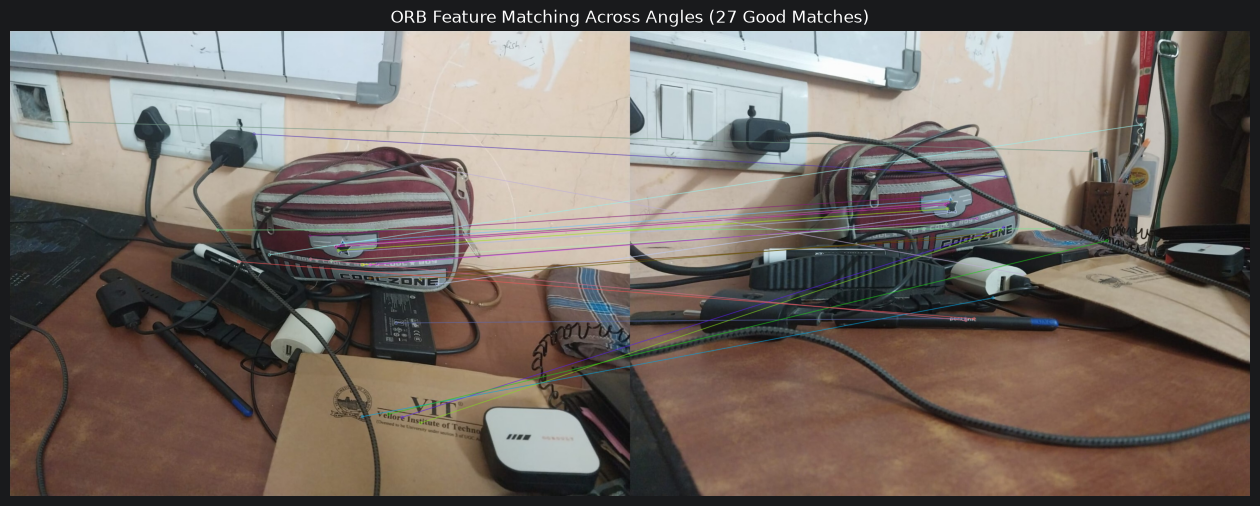

In [8]:
print("--- [TASK 7 FEATURE MATCHING LOG] ---")
print(f"Total Good Matches Found (After Ratio Test): {len(good_matches)}")
print("Dominant Object Cluster: High-contrast rigid items (e.g., printed pen bodies and watch faces)")
print("---------------------------------------")

# 5. Visualization
plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"ORB Feature Matching Across Angles ({len(good_matches)} Good Matches)")
plt.axis('off')
plt.show()